# SiT: Exploring Flow and Diffusion-based Generative Models with Scalable Interpolant Transformers

This notebook samples from pre-trained SiT models. SiTs are class-conSiTional latent interpolant models trained on ImageNet, unifying Flow and Diffusion Methods. 

[Paper]() | [GitHub](github.com/willisma/SiT)

# 1. Setup

We recommend using GPUs (Runtime > Change runtime type > Hardware accelerator > GPU). Run this cell to clone the SiT GitHub repo and setup PyTorch. You only have to run this once.

In [ ]:
import os
os.environ['PYTHONPATH'] = '/env/python'

import torch
from torchvision.utils import save_image
from diffusers.models import AutoencoderKL
from IPython.display import display
from PIL import Image

from transport import create_transport, Sampler
from download import find_model
from models import SiT_S_2

In [ ]:
torch.set_grad_enabled(False)
device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cpu":
    print("GPU not found. Using CPU instead.")

# Download SiT-XL/2 Models

In [ ]:
image_size = "128"
vae_model = "stabilityai/sd-vae-ft-ema"
latent_size = int(image_size) // 8
model = SiT_S_2(input_size=latent_size, num_classes=1).to(device)
state_dict = find_model("results/004-SiT-S-2-Linear-velocity-None/checkpoints/0010000.pt")

for name, param in state_dict.items():
    print(name, param.shape) 
    print(param)                

model.load_state_dict(state_dict)
model.eval() 
vae = AutoencoderKL.from_pretrained(vae_model).to(device)

# 2. Sample from Pre-trained SiT Models

You can customize several sampling options. For the full list of ImageNet classes, [check out this](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a).

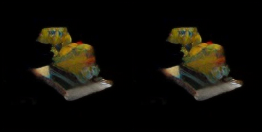

In [ ]:
seed = 69 
torch.manual_seed(seed)
num_sampling_steps = 250 
cfg_scale = 1 
class_labels = [0] 
samples_per_row = 4 
sampler_type = "ODE"


transport = create_transport()
sampler = Sampler(transport)

n = len(class_labels)
z = torch.randn(n, 4, latent_size, latent_size, device=device)
y = torch.tensor(class_labels, device=device)

z = torch.cat([z, z], 0)
y_null = torch.tensor([1] * n, device=device)
y = torch.cat([y, y_null], 0)
model_kwargs = dict(y=y, cfg_scale=cfg_scale)

if sampler_type == "SDE":
    SDE_sampling_method = "Euler" 
    diffusion_form = "linear"
    diffusion_norm = 1
    last_step = "Mean"
    last_step_size = 0.4
    sample_fn = sampler.sample_sde(
        sampling_method=SDE_sampling_method,
        diffusion_form=diffusion_form, 
        diffusion_norm=diffusion_norm,
        last_step_size=last_step_size, 
        num_steps=num_sampling_steps,
    ) 
elif sampler_type == "ODE":
    ODE_sampling_method = "dopri5" 
    atol = 1e-6
    rtol = 1e-3
    sample_fn = sampler.sample_ode(
        sampling_method=ODE_sampling_method,
        atol=atol,
        rtol=rtol,
        num_steps=num_sampling_steps
    ) 
samples = sample_fn(z, model.forward_with_cfg, **model_kwargs)[-1]
samples = vae.decode(samples / 0.18215).sample

save_image(samples, "sample.png", nrow=int(samples_per_row), 
           normalize=True, value_range=(-1, 1))
samples = Image.open("sample.png")
display(samples)